
# Class specialists analysis — cleaned notebook

Core steps needed for:

- bot/IP removal
- Table 5: user class distribution and entropy
- Table 6: global class distribution baseline
- Table 7: smoothed KL divergence per user

In [2]:

import ipaddress
import numpy as np
import pandas as pd


## 1. Remove bots and IP users

In [3]:

def remove_bot_ip_users(
    df: pd.DataFrame,
    bot_list,
    user_col: str = "user",
    return_removed_users: bool = False,
    print_summary: bool = True,
):
    """
    Remove rows where the user is:
      1) in a curated bot list
      2) an IPv4/IPv6 address
      3) starts with 'bot' (case-insensitive)
      4) ends with 'bot' (case-insensitive)
    """
    if user_col not in df.columns:
        raise KeyError(f"Column {user_col!r} not found in dataframe")

    bot_set = {str(x).strip().casefold() for x in bot_list if pd.notna(x)}

    unique_users = pd.Index(df[user_col].dropna().astype(str).unique())
    user_s = unique_users.to_series(index=unique_users).str.strip()

    def is_ip_username(name: str) -> bool:
        try:
            ipaddress.ip_address(name)
            return True
        except ValueError:
            return False

    listed_bots_mask = user_s.str.casefold().isin(bot_set)
    ip_mask = user_s.map(is_ip_username)
    startswith_bot_mask = user_s.str.casefold().str.startswith("bot")
    endswith_bot_mask = user_s.str.casefold().str.endswith("bot")

    curated_bot_users = unique_users[listed_bots_mask]
    ip_users = unique_users[ip_mask]
    startswith_bot_users = unique_users[startswith_bot_mask]
    endswith_bot_users = unique_users[endswith_bot_mask]

    bad_users = unique_users[
        listed_bots_mask | ip_mask | startswith_bot_mask | endswith_bot_mask
    ]

    filtered = df.loc[~df[user_col].isin(bad_users)].copy()

    removed_rows = len(df) - len(filtered)
    stats = {
        "removed_unique_users_total": len(bad_users),
        "removed_rows_total": removed_rows,
        "curated_list_users": len(curated_bot_users),
        "ip_users": len(ip_users),
        "startswith_bot_users": len(startswith_bot_users),
        "endswith_bot_users": len(endswith_bot_users),
    }

    if print_summary:
        print(f"Removed unique users: {stats['removed_unique_users_total']}")
        print(f"Removed rows: {stats['removed_rows_total']}")
        print("Users matching each criterion:")
        print(f"  - curated bot list: {stats['curated_list_users']}")
        print(f"  - IP addresses: {stats['ip_users']}")
        print(f"  - names starting with 'bot': {stats['startswith_bot_users']}")
        print(f"  - names ending with 'bot': {stats['endswith_bot_users']}")

    if return_removed_users:
        return filtered, bad_users, stats
    return filtered


Table table4_agg_counts_merged.csv was built based on the counts of edits done by an user on a given class respecting the histociral type.
For instance if u1 added p1(s1,o1) and wdt:P31(s1,c1) and wdt:P31(s1,c2) exist at that specific time, then we count +1 edit on c1 and +1 edit on c2 done by u1. If along the way the classes change, then edits on s1 would lead to counts for other classes

In [4]:
import pandas as pd

df_table4 = pd.read_csv("../../../wd_history/table4_agg_counts_merged.csv")

In [5]:
import json

with open("wikidata_bots.json", "r", encoding="utf-8") as f:
    bot_list = json.load(f)

df_table4_clean, removed_users, stats = remove_bot_ip_users(
    df_table4,
    bot_list=bot_list,
    user_col="user",
    return_removed_users=True,
    print_summary=True,
)

Removed unique users: 650156
Removed rows: 1410783
Users matching each criterion:
  - curated bot list: 252
  - IP addresses: 649437
  - names starting with 'bot': 65
  - names ending with 'bot': 633


In [6]:
n_users_raw = df_table4["user"].nunique()
n_rows_raw = len(df_table4)

n_users_clean = df_table4_clean["user"].nunique()
n_rows_clean = len(df_table4_clean)

filter_summary = {
    "raw_users": n_users_raw,
    "removed_users": len(removed_users),
    "pct_users_removed": len(removed_users) / n_users_raw,
    "clean_users": n_users_clean,
    "raw_user_class_rows": n_rows_raw,
    "removed_user_class_rows": stats["removed_rows_total"],
    "pct_rows_removed": stats["removed_rows_total"] / n_rows_raw,
    "clean_user_class_rows": n_rows_clean,
}

filter_summary

{'raw_users': 820341,
 'removed_users': 650156,
 'pct_users_removed': 0.7925435885808463,
 'clean_users': 170185,
 'raw_user_class_rows': 4992300,
 'removed_user_class_rows': 1410783,
 'pct_rows_removed': 0.2825917913586924,
 'clean_user_class_rows': 3581517}

## 2. Prepare the working table for Tables 5–7

In [5]:

# Keep only the columns needed downstream
# Assumes df_table4_clean already exists

t4 = df_table4_clean[["user", "class", "edit_count"]].copy()
t4["user"] = t4["user"].astype("category")
t4["class"] = t4["class"].astype("category")
t4["edit_count"] = pd.to_numeric(t4["edit_count"], downcast="integer")

# Per-user totals
user_totals = (
    t4.groupby("user", observed=True, sort=False)["edit_count"]
      .sum()
      .rename("user_total_edits")
)

# Long-form user-class distribution
t4 = t4.join(user_totals, on="user")
t4["class_share"] = t4["edit_count"] / t4["user_total_edits"]

table5_distribution = t4[[
    "user", "class", "edit_count", "user_total_edits", "class_share"
]].copy()

table5_distribution.dtypes


user                category
class               category
edit_count             int32
user_total_edits       int32
class_share          float64
dtype: object

## 3. Table 5 — User class distribution and entropy

In [6]:

p = table5_distribution["class_share"].to_numpy(dtype=np.float64)
table5_distribution["entropy_term"] = -p * np.log2(p)

user_entropy = (
    table5_distribution.groupby("user", observed=True, sort=False)["entropy_term"]
    .sum()
    .rename("entropy")
    .reset_index()
)

table5_summary = (
    table5_distribution.groupby("user", observed=True, sort=False)
    .agg(
        total_edits=("user_total_edits", "first"),
        active_classes=("class", "size"),
        max_class_share=("class_share", "max"),
    )
    .reset_index()
    .merge(user_entropy, on="user", how="left")
)

table5_summary["normalized_entropy"] = np.where(
    table5_summary["active_classes"] > 1,
    table5_summary["entropy"] / np.log2(table5_summary["active_classes"]),
    0.0,
)
table5_summary["specialization_score"] = 1 - table5_summary["normalized_entropy"]

top2_per_user = (
    table5_distribution.sort_values(
        ["user", "class_share", "edit_count"],
        ascending=[True, False, False]
    )
    .groupby("user", observed=True, sort=False)
    .head(2)
    .copy()
)

top1 = (
    top2_per_user.groupby("user", observed=True, sort=False)
    .nth(0)[["class", "class_share"]]
    .rename(columns={"class": "top_class", "class_share": "top_class_share"})
    .reset_index()
)

top2 = (
    top2_per_user.groupby("user", observed=True, sort=False)
    .nth(1)[["class", "class_share"]]
    .rename(columns={"class": "second_class", "class_share": "second_class_share"})
    .reset_index()
)

table5_summary = (
    table5_summary
    .merge(top1, on="user", how="left")
    .merge(top2, on="user", how="left")
)

table5_summary["second_class_share"] = table5_summary["second_class_share"].fillna(0.0)
table5_summary["effective_classes"] = 2 ** table5_summary["entropy"]

table5_summary = table5_summary.sort_values(
    ["specialization_score", "total_edits"],
    ascending=[False, False]
).reset_index(drop=True)

table5_summary.head()


,user,total_edits,active_classes,max_class_share,entropy,normalized_entropy,specialization_score,top_class,top_class_share,second_class,second_class_share,effective_classes
0,Garyh.stern,66975,1,1.0,0.0,0.0,1.0,wd:Q2668072,1.0,NaN,0.0,1.0
1,Eugen Hiebeler,58359,1,1.0,0.0,0.0,1.0,wd:Q5,1.0,NaN,0.0,1.0
2,Romesditto23,16951,1,1.0,0.0,0.0,1.0,wd:Q5,1.0,NaN,0.0,1.0
3,Moritz Nitschmann,8896,1,1.0,0.0,0.0,1.0,wd:Q5,1.0,NaN,0.0,1.0
4,Sr. Martinez Quebracho,6729,1,1.0,0.0,0.0,1.0,wd:Q5,1.0,NaN,0.0,1.0


## 4. Table 6 — Global class distribution (baseline)

In [7]:

table6_global = (
    df_table4_clean.groupby("class", observed=True, sort=False)["edit_count"]
    .sum()
    .rename("global_edits")
    .reset_index()
)

total_edits_corpus = table6_global["global_edits"].sum()

table6_global["global_share"] = table6_global["global_edits"] / total_edits_corpus

table6_global = table6_global.sort_values(
    "global_share",
    ascending=False
).reset_index(drop=True)

table6_global.head()


,class,global_edits,global_share
0,wd:Q13442814,126603838,0.234246
1,wd:Q5,114227542,0.211347
2,wd:Q523,25385598,0.046969
3,wd:Q318,11710048,0.021666
4,wd:Q16521,10881589,0.020133


## 5. Helper utilities for labels and display

This section adds small utilities used in the rest of the notebook: plotting imports, a safe Wikidata label lookup helper, and a display helper for compact comparison tables.

In [20]:
import matplotlib.pyplot as plt
import requests
from IPython.display import display
import math
import time

def fetch_wikidata_labels(
    qids,
    lang="en",
    endpoint="https://query.wikidata.org/sparql",
    batch_size=50,
    max_retries=4,
    timeout=60,
    sleep_seconds=1.5,
    verbose=True,
):
    """
    Fetch labels for Wikidata QIDs using POST, batching, retries, and graceful fallback.

    Returns partial results if some batches fail.
    """
    qids = [str(q).strip() for q in qids if pd.notna(q)]
    qids = list(dict.fromkeys(qids))

    if not qids:
        return {}

    headers = {
        "Accept": "application/sparql-results+json",
        "User-Agent": "Mozilla/5.0 (compatible; class-specialists-notebook/1.0)",
        "Content-Type": "application/x-www-form-urlencoded",
    }

    label_map = {}
    n_batches = math.ceil(len(qids) / batch_size)

    for batch_idx, start in enumerate(range(0, len(qids), batch_size), start=1):
        batch = qids[start:start + batch_size]
        values = " ".join(batch)

        query = f"""
        SELECT ?s ?label WHERE {{
          VALUES ?s {{ {values} }}
          ?s rdfs:label ?label .
          FILTER (lang(?label) = "{lang}")
        }}
        """

        success = False

        for attempt in range(1, max_retries + 1):
            try:
                if verbose:
                    print(f"Label batch {batch_idx}/{n_batches}, attempt {attempt}/{max_retries}...")

                response = requests.post(
                    endpoint,
                    data={"query": query, "format": "json"},
                    headers=headers,
                    timeout=timeout,
                )
                response.raise_for_status()
                data = response.json()

                for row in data["results"]["bindings"]:
                    uri = row["s"]["value"]
                    label = row["label"]["value"]
                    qid = "wd:" + uri.rsplit("/", 1)[-1]
                    label_map[qid] = label

                success = True
                break

            except Exception as e:
                if verbose:
                    print(f"  Batch {batch_idx} failed: {e}")
                if attempt < max_retries:
                    time.sleep(sleep_seconds * attempt)

        if not success and verbose:
            print(f"Skipping batch {batch_idx}/{n_batches} after {max_retries} failed attempts.")

        time.sleep(sleep_seconds)

    # fallback: use qid itself when label missing
    for qid in qids:
        label_map.setdefault(qid, qid)

    return label_map


def safe_fetch_wikidata_labels(qids, lang="en"):
    try:
        return fetch_wikidata_labels(qids, lang=lang)
    except Exception as e:
        print(f"Label fetch skipped: {e}")
        return {}


def with_labels(series):
    qids = [x for x in pd.Series(series).dropna().astype(str).unique().tolist() if x.startswith("wd:")]
    label_map = safe_fetch_wikidata_labels(qids)
    return pd.Series(series).map(label_map).fillna(pd.Series(series))


## 6. Build baselines and sweep settings

This section creates all baseline variants only once so the notebook can be run sequentially without silently overwriting `results`. It also defines the threshold and smoothing grids used in the robustness sweep.

In [9]:
user_total_edits_all = (
    table5_distribution.groupby("user", observed=True, sort=False)["user_total_edits"]
    .first()
    .astype("int64")
)

# Load class-level prevalence counts used for alternative baselines and diagnostics
class_counts = pd.read_csv("class_add_delete_counts_with_total.csv")
class_counts["n_total_instances_added"] = pd.to_numeric(
    class_counts["n_total_instances_added"], errors="coerce"
).fillna(0)
class_counts["n_instances_deleted"] = pd.to_numeric(
    class_counts.get("n_instances_deleted", 0), errors="coerce"
).fillna(0)

# Pure edit baseline
baseline_edits = (
    df_table4_clean.groupby("class", observed=True, sort=False)["edit_count"]
    .sum()
    .rename("baseline_mass")
    .reset_index()
)
baseline_edits = baseline_edits.loc[baseline_edits["baseline_mass"] > 0].copy()
baseline_edits["baseline_type"] = "edit_count"

# Pure instance baseline
baseline_items_added = (
    class_counts[["class", "n_total_instances_added"]]
    .rename(columns={"n_total_instances_added": "baseline_mass"})
    .copy()
)
baseline_items_added = baseline_items_added.loc[baseline_items_added["baseline_mass"] > 0].copy()
baseline_items_added["baseline_type"] = "n_total_instances_added"

# Components for mixture baselines
edit_mass = (
    df_table4_clean.groupby("class", observed=True, sort=False)["edit_count"]
    .sum()
    .rename("edit_mass")
    .reset_index()
)
instance_mass = (
    class_counts[["class", "n_total_instances_added"]]
    .rename(columns={"n_total_instances_added": "instance_mass"})
    .copy()
)

baseline_components = (
    pd.DataFrame({"class": pd.Index(edit_mass["class"]).union(pd.Index(instance_mass["class"]))})
    .merge(edit_mass, on="class", how="left")
    .merge(instance_mass, on="class", how="left")
    .fillna({"edit_mass": 0.0, "instance_mass": 0.0})
    .copy()
)
baseline_components["edit_share"] = baseline_components["edit_mass"] / baseline_components["edit_mass"].sum()
baseline_components["instance_share"] = baseline_components["instance_mass"] / baseline_components["instance_mass"].sum()

baseline_variants = {
    "edit_count": baseline_edits,
    "n_total_instances_added": baseline_items_added,
}

mixture_lambdas = [0.25, 0.50, 0.75]
for lam in mixture_lambdas:
    b = baseline_components[["class", "edit_share", "instance_share"]].copy()
    b["baseline_mass"] = lam * b["edit_share"] + (1 - lam) * b["instance_share"]
    b = b.loc[b["baseline_mass"] > 0, ["class", "baseline_mass"]].copy()
    b["baseline_type"] = f"mixture_lambda_{lam:.2f}"
    baseline_variants[f"mixture_lambda_{lam:.2f}"] = b

candidate_thresholds = [20, 50, int(user_total_edits_all.median())]
candidate_thresholds = list(dict.fromkeys(candidate_thresholds))
candidate_alphas = [0.1, 0.5, 1.0]

print("Baselines:", sorted(baseline_variants.keys()))
print("Thresholds:", candidate_thresholds)
print("Alphas:", candidate_alphas)


Baselines: ['edit_count', 'mixture_lambda_0.25', 'mixture_lambda_0.50', 'mixture_lambda_0.75', 'n_total_instances_added']
Thresholds: [20, 50, 5]
Alphas: [0.1, 0.5, 1.0]


## 7. Define a robust specialist scoring function

This function applies the final safeguards: a minimum edit filter, an `active_classes >= 2` filter, recomputation of within-user class shares after filtering, a prevalence-aware smoothed KL baseline, and a `top_class_by_kl_contribution` field that identifies which class actually drives the KL signal.

In [10]:
def build_specialist_outputs(
    table5_distribution: pd.DataFrame,
    baseline_df: pd.DataFrame,
    min_total_edits: int,
    alpha: float = 0.5,
):
    user_totals = (
        table5_distribution.groupby("user", observed=True, sort=False)["user_total_edits"]
        .first()
        .astype("int64")
        .rename("total_edits")
        .reset_index()
    )

    eligible_users = user_totals.loc[user_totals["total_edits"] >= min_total_edits, "user"]
    d = table5_distribution.loc[table5_distribution["user"].isin(eligible_users)].copy()
    if d.empty:
        raise ValueError(f"No users meet min_total_edits >= {min_total_edits}")

    n_users_after_min_edits = d["user"].nunique()

    user_n_classes = (
        d.groupby("user", observed=True, sort=False)["class"]
        .size()
        .rename("active_classes_check")
    )
    eligible_multi = user_n_classes[user_n_classes >= 2].index
    d = d.loc[d["user"].isin(eligible_multi)].copy()
    if d.empty:
        raise ValueError(
            f"No users meet min_total_edits >= {min_total_edits} and active_classes >= 2"
        )

    n_users_after_class_filter = d["user"].nunique()

    # Defensive recomputation after all filtering
    d["user_total_edits_recomputed"] = (
        d.groupby("user", observed=True, sort=False)["edit_count"].transform("sum")
    )
    d["class_share"] = d["edit_count"] / d["user_total_edits_recomputed"]

    # Table 5 summary
    p = d["class_share"].to_numpy(dtype=np.float64)
    d["entropy_term"] = -p * np.log2(p)

    user_entropy = (
        d.groupby("user", observed=True, sort=False)["entropy_term"]
        .sum()
        .rename("entropy")
        .reset_index()
    )

    table5_summary_thr = (
        d.groupby("user", observed=True, sort=False)
        .agg(
            total_edits=("user_total_edits_recomputed", "first"),
            active_classes=("class", "size"),
            max_class_share=("class_share", "max"),
        )
        .reset_index()
        .merge(user_entropy, on="user", how="left")
    )

    table5_summary_thr["normalized_entropy"] = np.where(
        table5_summary_thr["active_classes"] > 1,
        table5_summary_thr["entropy"] / np.log2(table5_summary_thr["active_classes"]),
        0.0,
    )
    table5_summary_thr["specialization_score"] = 1 - table5_summary_thr["normalized_entropy"]

    top2 = (
        d.sort_values(["user", "class_share", "class"], ascending=[True, False, True])
        .groupby("user", observed=True, sort=False)
        .head(2)
        .assign(rank=lambda x: x.groupby("user", observed=True, sort=False).cumcount() + 1)
        .pivot(index="user", columns="rank", values=["class", "class_share"])
    )
    top2.columns = [
        "top_class" if (a, b) == ("class", 1) else
        "top_class_share" if (a, b) == ("class_share", 1) else
        "second_class" if (a, b) == ("class", 2) else
        "second_class_share"
        for a, b in top2.columns
    ]
    top2 = top2.reset_index()

    table5_summary_thr = table5_summary_thr.merge(top2, on="user", how="left")
    table5_summary_thr["second_class_share"] = table5_summary_thr["second_class_share"].fillna(0.0)

    # Table 7 KL
    classes_in_users = pd.Index(d["class"].unique())
    classes_in_baseline = pd.Index(baseline_df["class"].unique())
    all_classes = classes_in_users.union(classes_in_baseline)

    baseline = (
        pd.DataFrame({"class": all_classes})
        .merge(baseline_df[["class", "baseline_mass"]], on="class", how="left")
        .fillna({"baseline_mass": 0.0})
        .copy()
    )

    K = len(baseline)
    baseline["q_smoothed"] = (baseline["baseline_mass"] + alpha) / (baseline["baseline_mass"].sum() + alpha * K)

    table7_work = d[["user", "class", "edit_count"]].copy()
    table7_work["p_user"] = (
        table7_work["edit_count"] /
        table7_work.groupby("user", observed=True, sort=False)["edit_count"].transform("sum")
    )
    table7_work = table7_work.merge(
        baseline[["class", "q_smoothed"]],
        on="class",
        how="left",
        copy=False,
    )

    p = table7_work["p_user"].to_numpy(dtype=np.float64)
    q = table7_work["q_smoothed"].to_numpy(dtype=np.float64)
    table7_work["kl_term"] = p * np.log2(p / q)

    table7_divergence_thr = (
        table7_work.groupby("user", observed=True, sort=False)["kl_term"]
        .sum()
        .rename("kl_divergence_smoothed")
        .reset_index()
    )

    top_kl_class = (
        table7_work.sort_values(["user", "kl_term", "p_user", "class"], ascending=[True, False, False, True])
        .groupby("user", observed=True, sort=False)
        .head(1)[["user", "class", "kl_term", "p_user"]]
        .rename(columns={
            "class": "top_class_by_kl_contribution",
            "kl_term": "top_kl_term",
            "p_user": "top_class_by_kl_share",
        })
    )

    table7_divergence_thr = (
        table7_divergence_thr
        .merge(
            table5_summary_thr[[
                "user", "total_edits", "active_classes", "entropy", "normalized_entropy",
                "specialization_score", "max_class_share", "top_class", "top_class_share",
                "second_class", "second_class_share"
            ]],
            on="user", how="left"
        )
        .merge(top_kl_class, on="user", how="left")
        .sort_values(
            ["kl_divergence_smoothed", "specialization_score", "total_edits", "user"],
            ascending=[False, False, False, True]
        )
        .reset_index(drop=True)
    )

    audit = {
        "min_total_edits": int(min_total_edits),
        "alpha": float(alpha),
        "n_users_total": int(len(user_totals)),
        "n_users_eligible": int((user_totals["total_edits"] >= min_total_edits).sum()),
        "n_users_excluded": int((user_totals["total_edits"] < min_total_edits).sum()),
        "pct_users_excluded": float((user_totals["total_edits"] < min_total_edits).mean()),
        "median_total_edits": int(user_totals["total_edits"].median()),
        "n_users_after_min_edits": int(n_users_after_min_edits),
        "n_users_after_active_classes_ge_2": int(n_users_after_class_filter),
        "n_users_excluded_by_active_classes_ge_2": int(n_users_after_min_edits - n_users_after_class_filter),
        "pct_excluded_by_active_classes_ge_2": float(
            (n_users_after_min_edits - n_users_after_class_filter) / n_users_after_min_edits
        ),
    }

    return {
        "audit": audit,
        "table5_summary": table5_summary_thr,
        "table7_divergence": table7_divergence_thr,
        "table7_work": table7_work,
    }


## 8. Run the full robustness sweep

This section executes all baseline-threshold-alpha combinations exactly once and stores them in a single `results` dictionary. It also builds an audit table that records how many users are excluded by each filter choice.

In [12]:
results = {}

total_runs = len(baseline_variants) * len(candidate_thresholds) * len(candidate_alphas)
run_idx = 0

for baseline_name, baseline_df in baseline_variants.items():
    for threshold in candidate_thresholds:
        for alpha in candidate_alphas:
            run_idx += 1
            print(
                f"[{run_idx}/{total_runs}] "
                f"baseline={baseline_name} | min_edits={threshold} | alpha={alpha}"
            )
            results[(baseline_name, threshold, alpha)] = build_specialist_outputs(
                table5_distribution=table5_distribution,
                baseline_df=baseline_df,
                min_total_edits=threshold,
                alpha=alpha,
            )

print(f"Done. Computed {len(results)} model runs.")

[1/45] baseline=edit_count | min_edits=20 | alpha=0.1
[2/45] baseline=edit_count | min_edits=20 | alpha=0.5
[3/45] baseline=edit_count | min_edits=20 | alpha=1.0
[4/45] baseline=edit_count | min_edits=50 | alpha=0.1
[5/45] baseline=edit_count | min_edits=50 | alpha=0.5
[6/45] baseline=edit_count | min_edits=50 | alpha=1.0
[7/45] baseline=edit_count | min_edits=5 | alpha=0.1
[8/45] baseline=edit_count | min_edits=5 | alpha=0.5
[9/45] baseline=edit_count | min_edits=5 | alpha=1.0
[10/45] baseline=n_total_instances_added | min_edits=20 | alpha=0.1
[11/45] baseline=n_total_instances_added | min_edits=20 | alpha=0.5
[12/45] baseline=n_total_instances_added | min_edits=20 | alpha=1.0
[13/45] baseline=n_total_instances_added | min_edits=50 | alpha=0.1
[14/45] baseline=n_total_instances_added | min_edits=50 | alpha=0.5
[15/45] baseline=n_total_instances_added | min_edits=50 | alpha=1.0
[16/45] baseline=n_total_instances_added | min_edits=5 | alpha=0.1
[17/45] baseline=n_total_instances_added |

## 9. Compare candidate model specifications before selecting the final one

This section compares the edit-based and instance-based baselines at the main threshold (`min_total_edits = 50`) and across smoothing values. It also summarizes the top-ranked users for every baseline so the final model choice is motivated by the data.

In [13]:
comparison_rows = []

for alpha in candidate_alphas:
    res_edit = results[("edit_count", 50, alpha)]["table7_divergence"]
    res_inst = results[("n_total_instances_added", 50, alpha)]["table7_divergence"]

    merged = res_edit[["user", "kl_divergence_smoothed"]].merge(
        res_inst[["user", "kl_divergence_smoothed"]],
        on="user",
        suffixes=("_edit", "_inst")
    )

    shared_top10 = len(set(res_edit.head(10)["user"]).intersection(set(res_inst.head(10)["user"])))
    spearman = merged[["kl_divergence_smoothed_edit", "kl_divergence_smoothed_inst"]].corr(method="spearman").iloc[0, 1]

    comparison_rows.append({
        "alpha": alpha,
        "shared_top10_edit_vs_instance": shared_top10,
        "spearman_edit_vs_instance": spearman,
    })

model_selection_df = pd.DataFrame(comparison_rows)

top_compare = pd.concat(
    [
        res["table7_divergence"].head(10).assign(
            baseline=baseline_name,
            threshold_label=f"min_edits_{threshold}",
            alpha=alpha,
        )
        for (baseline_name, threshold, alpha), res in results.items()
    ],
    ignore_index=True,
)

display(model_selection_df)
display(
    top_compare.loc[top_compare["alpha"].eq(0.5), [
        "baseline", "threshold_label", "user", "kl_divergence_smoothed", "total_edits",
        "active_classes", "top_class_share", "second_class_share", "top_class_by_kl_contribution", "top_kl_term"
    ]]
)


,alpha,shared_top10_edit_vs_instance,spearman_edit_vs_instance
0,0.1,5,0.987043
1,0.5,5,0.987045
2,1.0,5,0.987048


,baseline,threshold_label,user,kl_divergence_smoothed,total_edits,active_classes,top_class_share,second_class_share,top_class_by_kl_contribution,top_kl_term
10,edit_count,min_edits_20,Super duck,24.497145,20,4,0.35,0.350000,wd:Q19892278,8.605936
11,edit_count,min_edits_20,Cartway,23.985599,23,5,0.391304,0.347826,wd:Q19059292,9.443212
12,edit_count,min_edits_20,WhiteCliffShepherds,23.541768,28,3,0.5,0.428571,wd:Q13342461,11.900199
13,edit_count,min_edits_20,Ceppeo,23.267965,27,2,0.925926,0.074074,wd:Q55236637,22.431847
14,edit_count,min_edits_20,Tiffanypaul61,23.178778,35,5,0.257143,0.228571,wd:Q370563,6.120660
...,...,...,...,...,...,...,...,...,...,...
435,mixture_lambda_0.75,min_edits_5,Kaybdc,17.343659,163253,2,0.999957,0.000043,wd:Q2668072,17.343557
436,mixture_lambda_0.75,min_edits_5,JuliKrue,17.343473,4989,2,0.999198,0.000802,wd:Q118867680,17.337805
437,mixture_lambda_0.75,min_edits_5,LucaDrBiondi,17.343105,1955865,5,0.999945,0.000052,wd:Q43305660,17.342950
438,mixture_lambda_0.75,min_edits_5,Omar.idma,17.342769,68781,5,0.999389,0.000436,wd:Q113813711,17.339596


## 10. Select the main specification and build the final tables

After reviewing the robustness comparisons, this section fixes the main specification used for the qualitative interpretation and figures: the instance-based baseline, a minimum of 50 total edits, and Jeffreys smoothing (`alpha = 0.5`).

In [21]:
MAIN_BASELINE = "n_total_instances_added"
MAIN_MIN_EDITS = 50
MAIN_ALPHA = 0.5

final_table5 = results[(MAIN_BASELINE, MAIN_MIN_EDITS, MAIN_ALPHA)]["table5_summary"].copy()
final_table7 = results[(MAIN_BASELINE, MAIN_MIN_EDITS, MAIN_ALPHA)]["table7_divergence"].copy()

final_table5 = final_table5.sort_values(
    ["specialization_score", "total_edits", "max_class_share", "user"],
    ascending=[False, False, False, True],
).reset_index(drop=True)

final_table7[["top_class_label", "second_class_label", "top_class_by_kl_label"]] = ""
label_map = safe_fetch_wikidata_labels(pd.unique(pd.concat([
    final_table7["top_class"].dropna(),
    final_table7["second_class"].dropna(),
    final_table7["top_class_by_kl_contribution"].dropna(),
], ignore_index=True)))

final_table7["top_class_label"] = final_table7["top_class"].map(label_map).fillna(final_table7["top_class"])
final_table7["second_class_label"] = final_table7["second_class"].map(label_map).fillna(final_table7["second_class"])
final_table7["top_class_by_kl_label"] = final_table7["top_class_by_kl_contribution"].map(label_map).fillna(final_table7["top_class_by_kl_contribution"])

print("Main specification:", MAIN_BASELINE, MAIN_MIN_EDITS, MAIN_ALPHA)
display(final_table7.head(20))


Label batch 1/155, attempt 1/4...
Label batch 2/155, attempt 1/4...
Label batch 3/155, attempt 1/4...
Label batch 4/155, attempt 1/4...
Label batch 5/155, attempt 1/4...
Label batch 6/155, attempt 1/4...
Label batch 7/155, attempt 1/4...
Label batch 8/155, attempt 1/4...
Label batch 9/155, attempt 1/4...
Label batch 10/155, attempt 1/4...
Label batch 11/155, attempt 1/4...
Label batch 12/155, attempt 1/4...
Label batch 13/155, attempt 1/4...
Label batch 14/155, attempt 1/4...
Label batch 15/155, attempt 1/4...
Label batch 16/155, attempt 1/4...
Label batch 17/155, attempt 1/4...
Label batch 18/155, attempt 1/4...
Label batch 19/155, attempt 1/4...
Label batch 20/155, attempt 1/4...
Label batch 21/155, attempt 1/4...
Label batch 22/155, attempt 1/4...
Label batch 23/155, attempt 1/4...
Label batch 24/155, attempt 1/4...
Label batch 25/155, attempt 1/4...
Label batch 26/155, attempt 1/4...
Label batch 27/155, attempt 1/4...
Label batch 28/155, attempt 1/4...
Label batch 29/155, attempt 1

,user,kl_divergence_smoothed,total_edits,active_classes,entropy,normalized_entropy,specialization_score,max_class_share,top_class,top_class_share,second_class,second_class_share,top_class_by_kl_contribution,top_kl_term,top_class_by_kl_share,top_class_label,second_class_label,top_class_by_kl_label
0,Laurenownerscounsel,23.672455,57,3,1.583630,0.999159,0.000841,0.350877,wd:Q166332,0.350877,wd:Q11917765,0.333333,wd:Q166332,8.113597,0.350877,eminent domain,right to property,eminent domain
1,Masquernya,23.241187,64,2,0.200622,0.200622,0.799378,0.968750,wd:Q11511388,0.96875,wd:Q11538952,0.031250,wd:Q11511388,22.776192,0.968750,wd:Q11511388,Shogi tournament,wd:Q11511388
2,Mrnmnl,23.120356,119,2,0.070012,0.070012,0.929988,0.991597,wd:Q2467310,0.991597,wd:Q1134686,0.008403,wd:Q2467310,23.073365,0.991597,UML tool,frazione,UML tool
3,Jose Félix Diaz,22.615408,93,9,3.112853,0.981996,0.018004,0.204301,wd:Q16865575,0.204301,wd:Q14346236,0.107527,wd:Q16865575,4.738044,0.204301,wd:Q16865575,Jorge,wd:Q16865575
4,Priyasekar1,22.343180,82,6,2.091537,0.809117,0.190883,0.426829,wd:Q445019,0.426829,wd:Q229750,0.268293,wd:Q445019,9.866986,0.426829,software,Kompagni,software
5,Magicalreview,22.312112,117,4,0.589173,0.294586,0.705414,0.888889,wd:Q94354106,0.888889,wd:Q5,0.094017,wd:Q94354106,22.068764,0.888889,wd:Q94354106,human,wd:Q94354106
6,Lawfirmammons,22.202072,54,4,1.995043,0.997522,0.002478,0.277778,wd:Q40348,0.277778,wd:Q6585303,0.259259,wd:Q6585303,6.101713,0.259259,lawyer,personal injury lawyer,personal injury lawyer
7,G Balory,22.184754,80,6,1.890103,0.731192,0.268808,0.362500,wd:Q2114844,0.3625,wd:Q1146002,0.350000,wd:Q2114844,8.973952,0.362500,taxidermist,cabinet of curiosities,taxidermist
8,ZuzanaBrabcova,22.070340,305,6,0.437919,0.169410,0.830590,0.937705,wd:Q65518705,0.937705,wd:Q101965,0.039344,wd:Q65518705,21.255380,0.937705,chemical demonstration,experiment,chemical demonstration
9,Coljo17,22.020032,162,6,1.001061,0.387263,0.612737,0.827160,wd:Q7445636,0.82716,wd:Q163740,0.067901,wd:Q7445636,19.711597,0.827160,seed library,nonprofit organization,seed library


## 11. Qualitative validation of high-KL user profiles

This section provides a concrete qualitative check for a few high-KL users by showing their leading edited classes and comparing the largest-volume class with the class that contributes most to KL divergence. This helps verify that the specialization signal reflects class-specific editing patterns rather than a misleading volume-only summary.

In [22]:
users_to_validate = final_table7.head(3)["user"].tolist()

user_profiles = (
    df_table4_clean.loc[df_table4_clean["user"].isin(users_to_validate)]
    .groupby(["user", "class"], observed=True, sort=False)["edit_count"]
    .sum()
    .reset_index()
)
user_profiles["class_share_within_user"] = (
    user_profiles["edit_count"] /
    user_profiles.groupby("user", observed=True, sort=False)["edit_count"].transform("sum")
)

profile_label_map = safe_fetch_wikidata_labels(user_profiles["class"].dropna().unique().tolist())
user_profiles["class_label"] = user_profiles["class"].map(profile_label_map).fillna(user_profiles["class"])

validated_profiles = (
    user_profiles.sort_values(["user", "edit_count"], ascending=[True, False])
    .groupby("user", observed=True, sort=False)
    .head(10)
)

summary_profiles = final_table7.head(10)[[
    "user", "kl_divergence_smoothed", "total_edits", "active_classes",
    "top_class", "top_class_label", "top_class_share",
    "top_class_by_kl_contribution", "top_class_by_kl_label", "top_kl_term"
]]

display(summary_profiles)
display(validated_profiles)


Label batch 1/1, attempt 1/4...
  Batch 1 failed: 429 Client Error: Too Many Requests for url: https://query.wikidata.org/sparql
Label batch 1/1, attempt 2/4...


,user,kl_divergence_smoothed,total_edits,active_classes,top_class,top_class_label,top_class_share,top_class_by_kl_contribution,top_class_by_kl_label,top_kl_term
0,Laurenownerscounsel,23.672455,57,3,wd:Q166332,eminent domain,0.350877,wd:Q166332,eminent domain,8.113597
1,Masquernya,23.241187,64,2,wd:Q11511388,wd:Q11511388,0.96875,wd:Q11511388,wd:Q11511388,22.776192
2,Mrnmnl,23.120356,119,2,wd:Q2467310,UML tool,0.991597,wd:Q2467310,UML tool,23.073365
3,Jose Félix Diaz,22.615408,93,9,wd:Q16865575,wd:Q16865575,0.204301,wd:Q16865575,wd:Q16865575,4.738044
4,Priyasekar1,22.343180,82,6,wd:Q445019,software,0.426829,wd:Q445019,software,9.866986
5,Magicalreview,22.312112,117,4,wd:Q94354106,wd:Q94354106,0.888889,wd:Q94354106,wd:Q94354106,22.068764
6,Lawfirmammons,22.202072,54,4,wd:Q40348,lawyer,0.277778,wd:Q6585303,personal injury lawyer,6.101713
7,G Balory,22.184754,80,6,wd:Q2114844,taxidermist,0.3625,wd:Q2114844,taxidermist,8.973952
8,ZuzanaBrabcova,22.070340,305,6,wd:Q65518705,chemical demonstration,0.937705,wd:Q65518705,chemical demonstration,21.255380
9,Coljo17,22.020032,162,6,wd:Q7445636,seed library,0.82716,wd:Q7445636,seed library,19.711597


,user,class,edit_count,class_share_within_user,class_label
1,Laurenownerscounsel,wd:Q166332,20,0.350877,eminent domain
0,Laurenownerscounsel,wd:Q11917765,19,0.333333,right to property
2,Laurenownerscounsel,wd:Q6060359,18,0.315789,Inverse condemnation
3,Masquernya,wd:Q11511388,62,0.968750,wd:Q11511388
4,Masquernya,wd:Q11538952,2,0.031250,Shogi tournament
6,Mrnmnl,wd:Q2467310,118,0.991597,UML tool
5,Mrnmnl,wd:Q1134686,1,0.008403,frazione


## 12. Plot the strongest user-level specialist signals

These plots summarize the main user-level story under the selected specification: who the highest-KL specialists are and how concentrated their dominant classes remain after applying the quality filters.

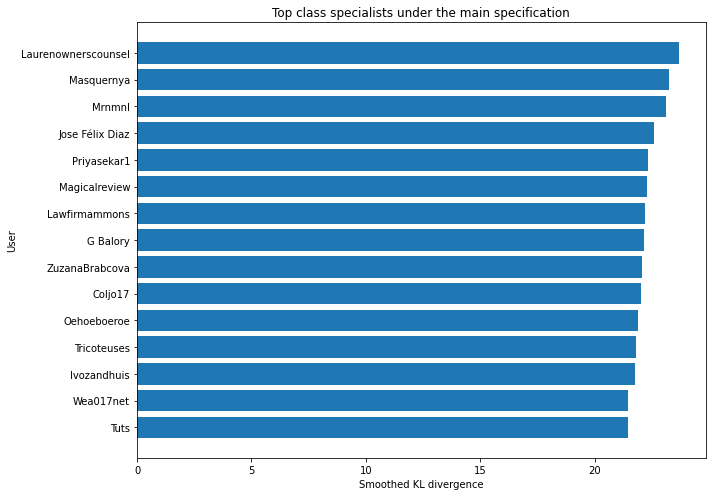

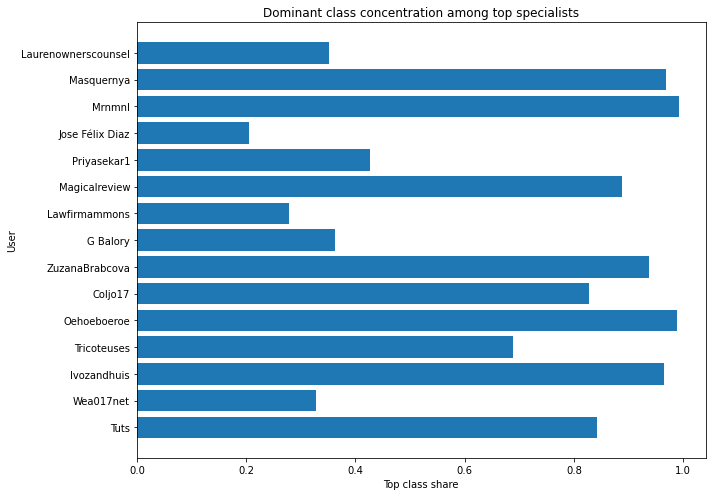

In [23]:
plot_df = final_table7.head(15).copy().sort_values("kl_divergence_smoothed", ascending=True)

plt.figure(figsize=(10, 7))
plt.barh(plot_df["user"], plot_df["kl_divergence_smoothed"])
plt.xlabel("Smoothed KL divergence")
plt.ylabel("User")
plt.title("Top class specialists under the main specification")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 7))
plt.barh(plot_df["user"], plot_df["top_class_share"])
plt.xlabel("Top class share")
plt.ylabel("User")
plt.title("Dominant class concentration among top specialists")
plt.tight_layout()
plt.show()


## 13. Plot class-level change intensity and prevalence

This section supports the baseline choice with simple class-level diagnostics. It compares total edit activity with the number of instances added to each class and highlights classes with especially high edit intensity per added instance, which can indicate more actively evolving knowledge.

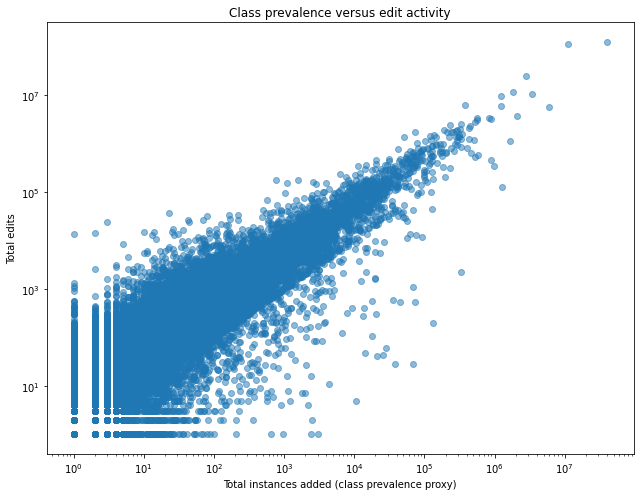

Label batch 1/1, attempt 1/4...


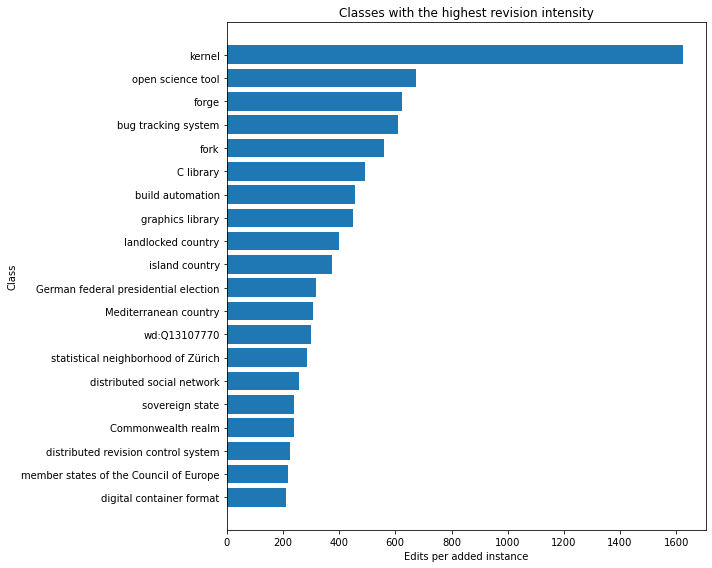

,class,class_label,total_edits,n_total_instances_added,n_instances_deleted,edits_per_added_instance,delete_rate_proxy
165084,wd:Q9662,kernel,37331.0,23,8,1623.086957,0.347826
125316,wd:Q52990223,open science tool,17535.0,26,8,674.423077,0.307692
97277,wd:Q3077240,forge,26878.0,43,9,625.069767,0.209302
164301,wd:Q956086,bug tracking system,15216.0,25,7,608.640000,0.280000
100820,wd:Q332903,fork,24648.0,44,12,560.181818,0.272727
94315,wd:Q29642875,C library,13257.0,27,5,491.000000,0.185185
88105,wd:Q2727468,build automation,16373.0,36,15,454.805556,0.416667
101641,wd:Q337820,graphics library,13927.0,31,4,449.258065,0.129032
28028,wd:Q123480,landlocked country,31701.0,79,40,401.278481,0.506329
13564,wd:Q112099,island country,26206.0,70,29,374.371429,0.414286


In [24]:
class_edit_totals = (
    df_table4_clean.groupby("class", observed=True, sort=False)["edit_count"]
    .sum()
    .rename("total_edits")
    .reset_index()
)

class_compare = (
    class_counts[["class", "n_instances_deleted", "n_total_instances_added"]]
    .merge(class_edit_totals, on="class", how="outer")
    .fillna({"n_instances_deleted": 0, "n_total_instances_added": 0, "total_edits": 0})
    .copy()
)
class_compare = class_compare.loc[
    (class_compare["total_edits"] > 0) | (class_compare["n_total_instances_added"] > 0)
].copy()
class_compare["edits_per_added_instance"] = np.where(
    class_compare["n_total_instances_added"] > 0,
    class_compare["total_edits"] / class_compare["n_total_instances_added"],
    np.nan,
)
class_compare["delete_rate_proxy"] = np.where(
    class_compare["n_total_instances_added"] > 0,
    class_compare["n_instances_deleted"] / class_compare["n_total_instances_added"],
    np.nan,
)

plt.figure(figsize=(9, 7))
plt.scatter(class_compare["n_total_instances_added"], class_compare["total_edits"], alpha=0.5)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Total instances added (class prevalence proxy)")
plt.ylabel("Total edits")
plt.title("Class prevalence versus edit activity")
plt.tight_layout()
plt.show()

intensity_df = class_compare.loc[class_compare["n_total_instances_added"] >= 20].copy()
intensity_df = intensity_df.sort_values("edits_per_added_instance", ascending=False).head(20)
intensity_label_map = safe_fetch_wikidata_labels(intensity_df["class"].tolist())
intensity_df["class_label"] = intensity_df["class"].map(intensity_label_map).fillna(intensity_df["class"])

plot_intensity = intensity_df.sort_values("edits_per_added_instance", ascending=True)
plt.figure(figsize=(10, 8))
plt.barh(plot_intensity["class_label"], plot_intensity["edits_per_added_instance"])
plt.xlabel("Edits per added instance")
plt.ylabel("Class")
plt.title("Classes with the highest revision intensity")
plt.tight_layout()
plt.show()

display(intensity_df[[
    "class", "class_label", "total_edits", "n_total_instances_added",
    "n_instances_deleted", "edits_per_added_instance", "delete_rate_proxy"
]])


## 14. Plot simple temporal patterns when timestamps are available

If the aggregated class-edit file includes a timestamp column, this section plots monthly edit activity for the most edited classes. If no timestamp is present, the notebook skips this step gracefully without failing.

In [ ]:
possible_time_cols = ["timestamp", "time", "revision_timestamp", "month"]
time_col = next((c for c in possible_time_cols if c in df_table4_clean.columns), None)

if time_col is None:
    print("No timestamp column found in df_table4_clean. Skipping temporal plots.")
else:
    df_time = df_table4_clean[["class", "edit_count", time_col]].copy()
    df_time[time_col] = pd.to_datetime(df_time[time_col], errors="coerce")
    df_time = df_time.dropna(subset=[time_col]).copy()
    df_time["month"] = df_time[time_col].dt.to_period("M").dt.to_timestamp()

    top_classes = (
        df_time.groupby("class", observed=True)["edit_count"]
        .sum()
        .sort_values(ascending=False)
        .head(8)
        .index
    )

    monthly = (
        df_time.loc[df_time["class"].isin(top_classes)]
        .groupby(["month", "class"], observed=True)["edit_count"]
        .sum()
        .reset_index()
    )
    monthly_label_map = safe_fetch_wikidata_labels(list(top_classes))
    monthly["class_label"] = monthly["class"].map(monthly_label_map).fillna(monthly["class"])

    plt.figure(figsize=(12, 7))
    for cls, sub in monthly.groupby("class_label", observed=True):
        plt.plot(sub["month"], sub["edit_count"], label=cls)

    plt.xlabel("Month")
    plt.ylabel("Edits")
    plt.title("Monthly edit activity for the most edited classes")
    plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()


## 15. Final interpretation for RQ2

This final section consolidates the main empirical takeaways from the robustness checks, the qualitative validation tables, and the figures so the notebook ends with a concise answer to the research question.

In [ ]:
print(
    "RQ2 conclusion:
"
    "Yes, Wikidata editing shows class-level specialization, but only after controlling for low-volume and degenerate users.

"
    "Under the selected specification (instance-based baseline, minimum 50 edits, active_classes >= 2, alpha = 0.5),
"
    "the top-ranked users remain strongly concentrated in particular semantic classes, and the class driving KL divergence
"
    "is not always the same as the class with the largest raw edit share. This supports a qualified positive answer to RQ2: 
"
    "some users do disproportionately edit entities of particular semantic classes, indicating genuine class-level specialization.

"
    "The instance-based baseline is preferred because class-level diagnostics show that some classes attract many more edits per added instance
"
    "than others. An edit-based baseline would overweight these repeatedly revised classes relative to their prevalence.
"
)


# Manual inspection

In [26]:
final_table7.head(10)

,user,kl_divergence_smoothed,total_edits,active_classes,entropy,normalized_entropy,specialization_score,max_class_share,top_class,top_class_share,second_class,second_class_share,top_class_by_kl_contribution,top_kl_term,top_class_by_kl_share,top_class_label,second_class_label,top_class_by_kl_label
0,Laurenownerscounsel,23.672455,57,3,1.583630,0.999159,0.000841,0.350877,wd:Q166332,0.350877,wd:Q11917765,0.333333,wd:Q166332,8.113597,0.350877,eminent domain,right to property,eminent domain
1,Masquernya,23.241187,64,2,0.200622,0.200622,0.799378,0.968750,wd:Q11511388,0.96875,wd:Q11538952,0.031250,wd:Q11511388,22.776192,0.968750,wd:Q11511388,Shogi tournament,wd:Q11511388
2,Mrnmnl,23.120356,119,2,0.070012,0.070012,0.929988,0.991597,wd:Q2467310,0.991597,wd:Q1134686,0.008403,wd:Q2467310,23.073365,0.991597,UML tool,frazione,UML tool
3,Jose Félix Diaz,22.615408,93,9,3.112853,0.981996,0.018004,0.204301,wd:Q16865575,0.204301,wd:Q14346236,0.107527,wd:Q16865575,4.738044,0.204301,wd:Q16865575,Jorge,wd:Q16865575
4,Priyasekar1,22.343180,82,6,2.091537,0.809117,0.190883,0.426829,wd:Q445019,0.426829,wd:Q229750,0.268293,wd:Q445019,9.866986,0.426829,software,Kompagni,software
5,Magicalreview,22.312112,117,4,0.589173,0.294586,0.705414,0.888889,wd:Q94354106,0.888889,wd:Q5,0.094017,wd:Q94354106,22.068764,0.888889,wd:Q94354106,human,wd:Q94354106
6,Lawfirmammons,22.202072,54,4,1.995043,0.997522,0.002478,0.277778,wd:Q40348,0.277778,wd:Q6585303,0.259259,wd:Q6585303,6.101713,0.259259,lawyer,personal injury lawyer,personal injury lawyer
7,G Balory,22.184754,80,6,1.890103,0.731192,0.268808,0.362500,wd:Q2114844,0.3625,wd:Q1146002,0.350000,wd:Q2114844,8.973952,0.362500,taxidermist,cabinet of curiosities,taxidermist
8,ZuzanaBrabcova,22.070340,305,6,0.437919,0.169410,0.830590,0.937705,wd:Q65518705,0.937705,wd:Q101965,0.039344,wd:Q65518705,21.255380,0.937705,chemical demonstration,experiment,chemical demonstration
9,Coljo17,22.020032,162,6,1.001061,0.387263,0.612737,0.827160,wd:Q7445636,0.82716,wd:Q163740,0.067901,wd:Q7445636,19.711597,0.827160,seed library,nonprofit organization,seed library


In [28]:
def safe_label_map(qids, **kwargs):
    """
    Safe wrapper around fetch_wikidata_labels.

    Returns a {qid: label} mapping.
    If label fetching fails, falls back to {qid: qid}.
    """
    qids = [str(q).strip() for q in qids if pd.notna(q)]
    qids = list(dict.fromkeys(qids))

    if not qids:
        return {}

    try:
        return fetch_wikidata_labels(qids, **kwargs)
    except Exception as e:
        print(f"Label fetch skipped: {e}")
        return {qid: qid for qid in qids}

In [30]:
multi_class_users = ["Laurenownerscounsel", "Lawfirmammons", "G Balory"]
narrow_specialists = ["Masquernya", "Mrnmnl", "ZuzanaBrabcova"]

for user_to_check in multi_class_users:
    profile = (
        df_table4_clean.loc[df_table4_clean["user"] == user_to_check]
        .groupby("class", observed=True, sort=False)["edit_count"]
        .sum()
        .reset_index()
        .sort_values("edit_count", ascending=False)
    )

    profile["class_share"] = profile["edit_count"] / profile["edit_count"].sum()

    label_map = safe_label_map(profile["class"].tolist())
    profile["class_label"] = profile["class"].map(label_map).fillna(profile["class"])
    
    print(user_to_check)
    print(profile.head(10))

Label batch 1/1, attempt 1/4...
Laurenownerscounsel
          class  edit_count  class_share           class_label
1    wd:Q166332          20     0.350877        eminent domain
0  wd:Q11917765          19     0.333333     right to property
2   wd:Q6060359          18     0.315789  Inverse condemnation
Label batch 1/1, attempt 1/4...
Lawfirmammons
         class  edit_count  class_share             class_label
2    wd:Q40348          15     0.277778                  lawyer
3  wd:Q6585303          14     0.259259  personal injury lawyer
0     wd:Q1439          13     0.240741                   Texas
1    wd:Q16555          12     0.222222                 Houston
Label batch 1/1, attempt 1/4...
G Balory
           class  edit_count  class_share             class_label
2    wd:Q2114844          29       0.3625             taxidermist
0    wd:Q1146002          28       0.3500  cabinet of curiosities
1  wd:Q125361823          18       0.2250           wd:Q125361823
3          wd:Q5         

In [31]:
for user_to_check in narrow_specialists:
    profile = (
        df_table4_clean.loc[df_table4_clean["user"] == user_to_check]
        .groupby("class", observed=True, sort=False)["edit_count"]
        .sum()
        .reset_index()
        .sort_values("edit_count", ascending=False)
    )

    profile["class_share"] = profile["edit_count"] / profile["edit_count"].sum()

    label_map = safe_label_map(profile["class"].tolist())
    profile["class_label"] = profile["class"].map(label_map).fillna(profile["class"])
    
    print(user_to_check)
    print(profile.head(10))

Label batch 1/1, attempt 1/4...
Masquernya
          class  edit_count  class_share       class_label
0  wd:Q11511388          62      0.96875      wd:Q11511388
1  wd:Q11538952           2      0.03125  Shogi tournament
Label batch 1/1, attempt 1/4...
Mrnmnl
         class  edit_count  class_share class_label
1  wd:Q2467310         118     0.991597    UML tool
0  wd:Q1134686           1     0.008403    frazione
Label batch 1/1, attempt 1/4...
ZuzanaBrabcova
          class  edit_count  class_share                 class_label
2  wd:Q65518705         286     0.937705      chemical demonstration
0    wd:Q101965          12     0.039344                  experiment
5    wd:Q834028           3     0.009836        laboratory equipment
1  wd:Q15711994           2     0.006557  group of isomeric entities
3    wd:Q657709           1     0.003279        laboratory glassware
4     wd:Q81163           1     0.003279                     polymer


In [32]:
broad_users = ["Jose Félix Diaz", "Priyasekar1"]

for user_to_check in broad_users:
    profile = (
        df_table4_clean.loc[df_table4_clean["user"] == user_to_check]
        .groupby("class", observed=True, sort=False)["edit_count"]
        .sum()
        .reset_index()
        .sort_values("edit_count", ascending=False)
    )

    profile["class_share"] = profile["edit_count"] / profile["edit_count"].sum()

    label_map = safe_label_map(profile["class"].tolist())
    profile["class_label"] = profile["class"].map(label_map).fillna(profile["class"])
    
    print(user_to_check)
    print(profile.head(10))

Label batch 1/1, attempt 1/4...
Jose Félix Diaz
          class  edit_count  class_share   class_label
1  wd:Q16865575          19     0.204301  wd:Q16865575
0  wd:Q14346236          10     0.107527         Jorge
4   wd:Q4164677          10     0.107527         Kadir
5    wd:Q482671          10     0.107527           Ana
6   wd:Q4925304          10     0.107527         Roger
3    wd:Q364977           9     0.096774        Adolfo
7   wd:Q5727354           9     0.096774       Betsabé
2   wd:Q3445675           8     0.086022        Roxana
8    wd:Q647872           8     0.086022          Irma
Label batch 1/1, attempt 1/4...
Priyasekar1
         class  edit_count  class_share            class_label
4   wd:Q445019          35     0.426829               software
2   wd:Q229750          22     0.268293               Kompagni
5   wd:Q963380           9     0.109756           service desk
1   wd:Q152361           8     0.097561                   ITIL
0  wd:Q1481411           7     0.085366  IT

### Hybrid specialist-profile typology

This typology combines data-derived concentration thresholds with interpretable breadth categories.

Concentration thresholds are derived from the observed distribution of `top_class_share`:
- high concentration = 90th percentile
- medium concentration = median

Breadth categories use fixed count-based bins for interpretability:
- narrow breadth: up to 3 active classes
- structured multi-class breadth: 4 to 15 active classes
- broad breadth: 16 or more active classes

These categories are descriptive and mutually exclusive.

In [43]:
profile_df = final_table7.copy()

share_hi = profile_df["top_class_share"].quantile(0.90)
share_mid = profile_df["top_class_share"].quantile(0.50)

cond_A = (
    (profile_df["top_class_share"] >= share_hi) &
    (profile_df["active_classes"] <= 3)
)

cond_B = (
    (profile_df["top_class_share"] >= share_mid) &
    (profile_df["top_class_share"] < share_hi) &
    (profile_df["active_classes"] >= 4) &
    (profile_df["active_classes"] <= 15)
)

cond_C = (
    (profile_df["top_class_share"] < 0.60) &
    (profile_df["active_classes"] >= 16)
)

profile_df["specialist_profile"] = np.select(
    [cond_A, cond_B, cond_C],
    [
        "A. Clear narrow specialists",
        "B. Structured multi-class users",
        "C. Broad but still high-KL users",
    ],
    default="Other"
)

profile_counts = (
    profile_df["specialist_profile"]
    .value_counts(dropna=False)
    .rename_axis("specialist_profile")
    .reset_index(name="n_users")
)
profile_counts["pct_users"] = profile_counts["n_users"] / profile_counts["n_users"].sum()

profile_counts

,specialist_profile,n_users,pct_users
0,C. Broad but still high-KL users,12315,0.423808
1,Other,10237,0.352295
2,B. Structured multi-class users,5282,0.181774
3,A. Clear narrow specialists,1224,0.042123


### Representative qualitative examples from each specialist-profile type

This table selects representative users from each profile type for manual inspection.
Examples are taken from the highest-KL users within each profile, making the qualitative section transparent and reproducible.

In [44]:
qual_examples = (
    profile_df.loc[profile_df["specialist_profile"] != "Other"]
    .sort_values(
        ["specialist_profile", "kl_divergence_smoothed", "total_edits"],
        ascending=[True, False, False]
    )
    .groupby("specialist_profile", observed=True, sort=False)
    .head(3)
    .copy()
)

qual_examples[[
    "specialist_profile",
    "user",
    "kl_divergence_smoothed",
    "total_edits",
    "active_classes",
    "top_class_label",
    "top_class_share",
    "second_class_label",
    "second_class_share",
    "top_class_by_kl_contribution",
    "top_class_by_kl_label",
    "top_kl_term"
]]

,specialist_profile,user,kl_divergence_smoothed,total_edits,active_classes,top_class_label,top_class_share,second_class_label,second_class_share,top_class_by_kl_contribution,top_class_by_kl_label,top_kl_term
1,A. Clear narrow specialists,Masquernya,23.241187,64,2,wd:Q11511388,0.96875,Shogi tournament,0.031250,wd:Q11511388,wd:Q11511388,22.776192
2,A. Clear narrow specialists,Mrnmnl,23.120356,119,2,UML tool,0.991597,frazione,0.008403,wd:Q2467310,UML tool,23.073365
10,A. Clear narrow specialists,Oehoeboeroe,21.909872,85,2,orthodox file manager,0.988235,file manager,0.011765,wd:Q2158576,orthodox file manager,21.747309
5,B. Structured multi-class users,Magicalreview,22.312112,117,4,wd:Q94354106,0.888889,human,0.094017,wd:Q94354106,wd:Q94354106,22.068764
9,B. Structured multi-class users,Coljo17,22.020032,162,6,seed library,0.82716,nonprofit organization,0.067901,wd:Q7445636,seed library,19.711597
11,B. Structured multi-class users,Tricoteuses,21.831412,119,8,french legislative session of the 15th legisla...,0.689076,15th legislature of the Fifth French Republic,0.084034,wd:Q87344584,french legislative session of the 15th legisla...,15.589314
45,C. Broad but still high-KL users,AlexAnnaTaylor,20.286804,571,28,wd:Q9340,0.070053,Dropbox,0.068301,wd:Q9340,wd:Q9340,1.516448
107,C. Broad but still high-KL users,LoveTW&CN,19.361441,1547,20,human,0.072398,YouTuber,0.056884,wd:Q57026211,Huaren,1.225830
114,C. Broad but still high-KL users,Ptypicalht2,19.312517,138,16,elementary particle,0.311594,manifold,0.152174,wd:Q43116,elementary particle,6.073913


In [45]:
top_k = 100

profile_counts_topk = (
    profile_df
    .sort_values(["kl_divergence_smoothed", "total_edits"], ascending=[False, False])
    .head(top_k)["specialist_profile"]
    .value_counts(dropna=False)
    .rename_axis("specialist_profile")
    .reset_index(name=f"n_users_top_{top_k}")
)

profile_counts_topk[f"pct_users_top_{top_k}"] = (
    profile_counts_topk[f"n_users_top_{top_k}"] / top_k
)

profile_counts_topk

,specialist_profile,n_users_top_100,pct_users_top_100
0,Other,60,0.60
1,B. Structured multi-class users,25,0.25
2,A. Clear narrow specialists,14,0.14
3,C. Broad but still high-KL users,1,0.01
